# Function 1 Analysis - Week 7

**Function Description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

**New datapoint (Week 7):** `(0.620490, 0.603926)` returned **≈0.35894**, a strong improvement and the **new maximum** (previous best ≈0.0848 at `(0.601042, 0.649989)`). We now track **16 datapoints** in total.

**Why we chose this point:** The BO followed the local-gradient PI loop on the upper-right ridge, nudging slightly toward `x2 < x1` to test the slope just below the prior max. This confirmed a sharper peak closer to the diagonal than the earlier `(0.601, 0.650)` point.

**Recommendation for next week:** Keep the local-gradient step but widen the neighbor radius (~0.20) and use a small step (≈0.04–0.06) while allowing mild `x2 < x1` moves. Probe just below the new peak to map the steep flank without leaving the x1≈0.60–0.64, x2≈0.58–0.62 zone.


## Loading and Displaying the Data

We load the inputs and outputs for function 1. The Week 7 query `(0.620490, 0.603926)` came back **≈0.35894 (new max)**, overtaking the Week 4 point `(0.601042, 0.649989)` at ≈0.0848 near the upper-right ridge. Datapoint 4 remains the lone strong negative outlier, kept for completeness.


In [21]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–6 new points
X_new_point_week_1 = np.array([[0.600000, 0.600000]])
y_new_point_week_1 = np.array([0.025559285339829783])
X_new_point_week_2 = np.array([[0.620000, 0.574000]])
y_new_point_week_2 = np.array([-0.00824324367890544])
X_new_point_week_3 = np.array([[0.483000, 0.528000]])
y_new_point_week_3 = np.array([1.0257314214244368e-11])
X_new_point_week_4 = np.array([[0.601042, 0.649989]])
y_new_point_week_4 = np.array([0.08476870094352708])
X_new_point_week_5 = np.array([[0.566815, 0.686438]])
y_new_point_week_5 = np.array([0.000011190518856399522])
X_new_point_week_6 = np.array([[0.620490, 0.603926]])
y_new_point_week_6 = np.array([0.3589371640727202])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


df sorted by y


,x1,x2,y
0,0.620490,0.603926,3.589372e-01
1,0.601042,0.649989,8.476870e-02
2,0.600000,0.600000,2.555929e-02
3,0.566815,0.686438,1.119052e-05
4,0.483000,0.528000,1.025731e-11
5,0.731024,0.733000,7.710875e-16
6,0.683418,0.861057,2.535001e-40
7,0.574329,0.879898,1.033078e-46
8,0.883890,0.582254,6.229856e-48
9,0.319404,0.762959,1.322677e-79


- **New point (Week 7):** `(0.620490, 0.603926)` returned **≈0.35894** — **new maximum**, improving on Week 4 `(0.601042, 0.649989)` at ≈0.0848.
- Recommendation for next BO step: keep the local-gradient step but **nudge toward x2 slightly below x1** (to probe the slope that yielded the new max) and widen the neighbor radius a bit (e.g., 0.20) to avoid overfitting the single high point. Consider a 0.04–0.06 step size with clipping to stay local.


## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


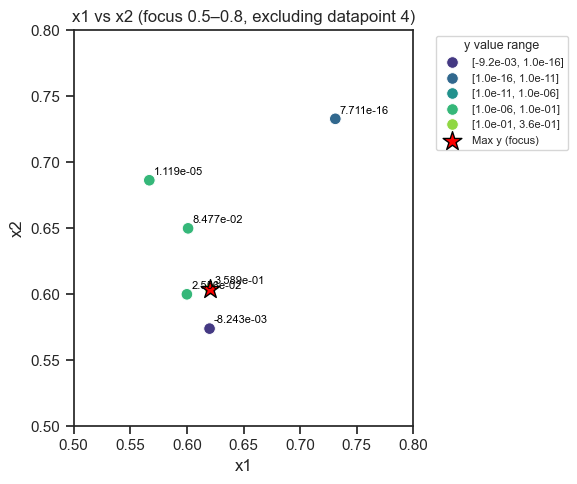

In [22]:
plt.figure(figsize=(6, 5))
df_plot = df.drop(index=4).copy()

# Filter to focus region
focus_mask = (df_plot["x1"].between(0.5, 0.8)) & (df_plot["x2"].between(0.5, 0.8))
df_focus = df_plot[focus_mask].copy()

# Bin for colour
y_vals = df_focus["y"]
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max + 1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]

df_focus["y_group"] = pd.cut(df_focus["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_focus["y_group"].cat.categories}
df_focus["y_label"] = df_focus["y_group"].map(label_map)

scatter = sns.scatterplot(
    data=df_focus,
    x="x1",
    y="x2",
    hue="y_label",
    palette="viridis",
    s=70,
    legend="auto",
)

max_idx = df_focus["y"].idxmax()
max_row = df_focus.loc[max_idx]
plt.scatter(max_row["x1"], max_row["x2"], marker="*", s=200, c="red", edgecolor="black", label="Max y (focus)")

for _, row in df_focus.iterrows():
    plt.text(row["x1"] + 0.004, row["x2"] + 0.004, f"{row['y']:.3e}", fontsize=8, color="black")

plt.xlim(0.5, 0.8)
plt.ylim(0.5, 0.8)
plt.title("x1 vs x2 (focus 0.5–0.8, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Local directional gradient around the current best

We now keep only the **gradient-based step** (no extra heuristics):
- Take the neighbours closest to the current max (excluding the outlier at index 4) and weight them by proximity.
- Fit a local weighted plane `y ≈ a*x1 + b*x2 + c`; the coefficients `(a, b)` are the local gradient.
- Normalise `(a, b)` to a unit direction and take a small step (0.05) from the max in that direction, clipping to `[0,1]^2`.

The plot shows just two points: the current max and the proposed step along the local gradient.


,x1,x2,y,note
max,0.620490,0.603926,0.358937,Current max
grad_step,0.592399,0.645289,NaN,Step along local gradient (weighted plane fit)


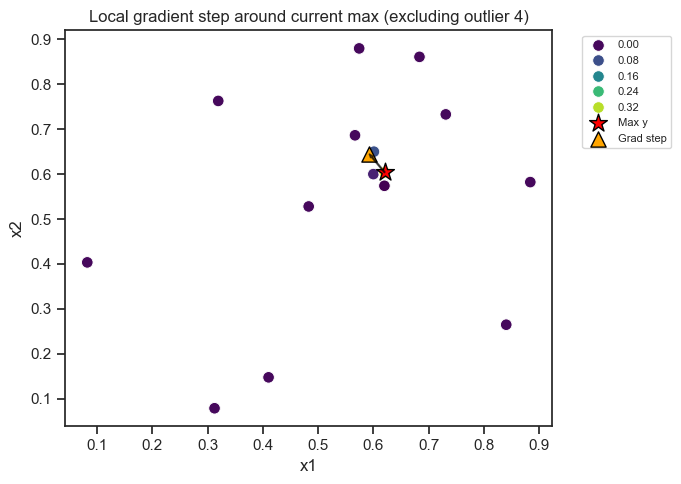

In [23]:
from sklearn.linear_model import LinearRegression

# Exclude the strong outlier at index 4 to avoid distorting the local fit
_df = df.drop(index=4).copy()
best_idx = _df["y"].idxmax()
best = _df.loc[best_idx, ["x1", "x2", "y"]]

# Nearest neighbours around the best point (exclude the best itself); keep it local
_df["dist_to_best"] = np.linalg.norm(_df[["x1", "x2"]].values - best[["x1", "x2"]].values, axis=1)
neighbor_radius = 0.18
neighbors_pool = _df.drop(index=best_idx)
neighbors = neighbors_pool[neighbors_pool["dist_to_best"] <= neighbor_radius]
if len(neighbors) < 3:  # fallback: take the closest few if radius is too tight
    neighbors = neighbors_pool.nsmallest(min(6, len(neighbors_pool)), "dist_to_best")

# Weighted local plane y ~= a*x1 + b*x2 + c
X_lin = neighbors[["x1", "x2"]].values
y_lin = neighbors["y"].values
weights = 1.0 / (neighbors["dist_to_best"].values + 1e-6)
linreg = LinearRegression()
linreg.fit(X_lin, y_lin, sample_weight=weights)

grad = linreg.coef_
grad_norm = np.linalg.norm(grad)
grad_dir = grad / grad_norm if grad_norm > 0 else np.zeros_like(grad)

step = 0.05  # small move to stay local
suggest_grad = np.clip(best[["x1", "x2"]].values + grad_dir * step, 0, 1)

summary = pd.DataFrame(
    {
        "x1": [best.x1, suggest_grad[0]],
        "x2": [best.x2, suggest_grad[1]],
        "y": [best.y, np.nan],
        "note": [
            "Current max",
            "Step along local gradient (weighted plane fit)",
        ],
    },
    index=["max", "grad_step"],
)

display(summary)

# Visualise gradient direction
plt.figure(figsize=(7, 5))
sns.scatterplot(data=_df, x="x1", y="x2", hue="y", palette="viridis", s=70, legend="auto")
plt.scatter(best.x1, best.x2, marker="*", s=180, c="red", edgecolor="black", label="Max y")
plt.scatter(*suggest_grad, marker="^", s=120, c="orange", edgecolor="black", label="Grad step")

plt.arrow(
    best.x1,
    best.x2,
    suggest_grad[0] - best.x1,
    suggest_grad[1] - best.x2,
    width=0.002,
    length_includes_head=True,
    color="black",
    alpha=0.6,
)

plt.title("Local gradient step around current max (excluding outlier 4)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



### How to interpret the gradient step
- **What it represents**: a small move (0.05 in Euclidean distance) from the current max in the direction of the locally fitted gradient `(a, b)`.
- **Why it works**: the weighted plane fit leans on the closest neighbours, so the step follows the steepest ascent suggested by nearby evidence while damping far-away noise.
- **If the slope is tiny**: when `||(a, b)|| ≈ 0`, the unit vector collapses to zero and the suggested point equals the current max; in that case lean on the EI shortlist below for movement.


## Bayesian optimisation (PI with min distance + min mean gain)

We switch back to **Probability of Improvement (PI)** and keep the search tightly centred on the incumbent while enforcing `x2 ≥ x1`. To avoid tiny nudges that sit almost on top of the best point, we require both a **minimum distance from the best** and a **minimum expected-mean increase** (mu gain) before considering a candidate.

Concretely, we:

1. Fit a GP surrogate on the observed points (excluding the outlier) using only the original features (no radial add-on), centred implicitly by the current max in the window.
2. Evaluate **Probability of Improvement** on a local window around the current max (small grid), not the whole `[0,1]^2`.
3. Keep the closed-form PI and **hard constraint `x2 ≥ x1`** to avoid the direction that yielded the negative reading.
4. Filter candidates to be at least a small step away from the current max (now 0.0 to allow touching the rim) **and** to clear a minimum expected-mean gain (0.0). We do **not** threshold PI; we simply maximise it after these filters.

`candidate_df_feasible` below lists the top PI points in that local neighbourhood after these filters; the plot highlights the local maximiser.


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,mu_gain,dist_to_best
5,0.610996,0.613420,0.138270,0.084378,-0.220667,0.013426
8,0.614794,0.617217,0.128982,0.086923,-0.229955,0.014460
2,0.607199,0.609622,0.113816,0.079817,-0.245122,0.014460
7,0.610996,0.617217,0.104515,0.088328,-0.254422,0.016334
11,0.618591,0.621015,0.099735,0.089371,-0.259202,0.017194


Suggested next query (max posterior mean, x2>=x1, max step): (0.611, 0.613)
Posterior mean: 0.1383, gain vs best: -0.2207, std: 0.0844


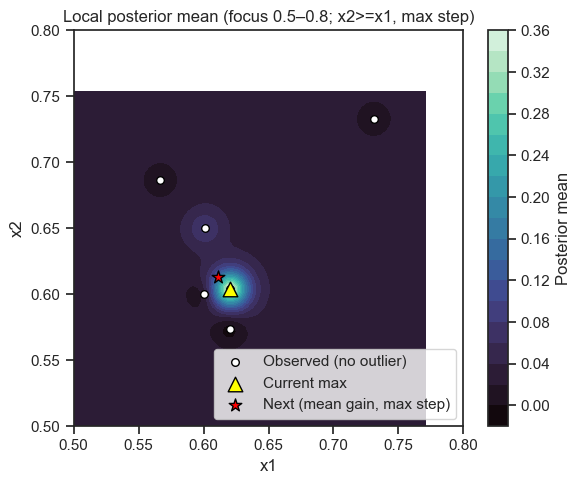

In [26]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

df_ei = df.drop(index=4).copy()
X_train = df_ei[["x1", "x2"]].values
y_train = df_ei["y"].values
best_ei = df_ei.loc[df_ei["y"].idxmax(), ["x1", "x2"]]

# Train a GP surrogate (no radial feature) with a smoother kernel and shorter length scales
kernel = ConstantKernel(1.0, (1e-2, 10.0)) * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 1.5), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X_train, y_train)

# Evaluate a dense grid of candidates in a local window around the best point
local_r = 0.15
x1_min, x1_max = max(best_ei.x1 - local_r, 0.0), min(best_ei.x1 + local_r, 1.0)
x2_min, x2_max = max(best_ei.x2 - local_r, 0.0), min(best_ei.x2 + local_r, 1.0)
grid_x1 = np.linspace(x1_min, x1_max, 80)
grid_x2 = np.linspace(x2_min, x2_max, 80)
mesh = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y_train.max()
xi = 0.02  # small xi to stay exploitative locally

# Posterior mean gain (no EI weighting)

mu_gain = mu - y_best  # expected mean improvement over incumbent

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["mu_gain"] = mu_gain

# HARD CONSTRAINTS: enforce x2 >= x1 and a maximum distance from best
candidate_df["dist_to_best"] = np.linalg.norm(candidate_df[["x1", "x2"]].values - best_ei.values, axis=1)
max_step = 0.02  # cap how far we move from the incumbent
candidate_df_feasible = candidate_df[
    (candidate_df["x2"] >= candidate_df["x1"]) &
    (candidate_df["dist_to_best"] <= max_step)
].reset_index(drop=True)

next_point = candidate_df_feasible.loc[candidate_df_feasible["mu_gain"].idxmax()]

display(candidate_df_feasible.nlargest(5, "mu_gain"))
print(f"Suggested next query (max posterior mean, x2>=x1, max step): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, gain vs best: {next_point.mu_gain:.4f}, std: {next_point.sigma:.4f}")

# Visualise posterior mean surface with current observations and recommended point
mu_grid = candidate_df["mu"].values.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6, 5))
contour = plt.contourf(grid_x1, grid_x2, mu_grid, levels=20, cmap="mako")
plt.colorbar(contour, label="Posterior mean")
plt.scatter(df_ei["x1"], df_ei["x2"], c="white", s=30, edgecolor="black", label="Observed (no outlier)")

# Highlight current max and next
plt.scatter(best_ei.x1, best_ei.x2, c="yellow", s=110, marker="^", edgecolor="black", label="Current max")
plt.scatter(next_point.x1, next_point.x2, c="red", s=90, marker="*", edgecolor="black", label="Next (mean gain, max step)")

# Focused view 0.5–0.8
plt.xlim(0.5, 0.8)
plt.ylim(0.5, 0.8)
plt.title("Local posterior mean (focus 0.5–0.8; x2>=x1, max step)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final shortlist of candidate moves
The table below consolidates the local gradient-based suggestions and the top local PI points (constrained to stay near the max and with `x2 ≥ x1`). Pick the point you prefer; I recommend favouring the gradient step if its slope is non-zero; otherwise use the highest-PI option that passes the min-step/min-PI and min-mean-gain filters.


In [25]:
options = []

if "summary" in globals():
    opt = summary.reset_index().rename(columns={"index": "id"})
    opt["source"] = "local_gradient"
    opt = opt[["source", "id", "x1", "x2", "note", "y"]]
    options.append(opt)

if "candidate_df_feasible" in globals():
    top_mean = candidate_df_feasible.nlargest(3, "mu_gain").copy()
    top_mean["id"] = [f"mu_top_{i+1}" for i in range(len(top_mean))]
    top_mean["note"] = "Local posterior mean (x2>=x1, max step)"
    top_mean["source"] = "local_mean"
    top_mean = top_mean[["source", "id", "x1", "x2", "note", "mu_gain", "mu", "sigma"]]
    options.append(top_mean)

if options:
    final_options = pd.concat(options, ignore_index=True)
    display(final_options)
else:
    print("Run the gradient and EI cells first to populate options.")



,source,id,x1,x2,note,y,mu_gain,mu,sigma
0,local_gradient,max,0.620490,0.603926,Current max,0.358937,NaN,NaN,NaN
1,local_gradient,grad_step,0.592399,0.645289,Step along local gradient (weighted plane fit),NaN,NaN,NaN,NaN
2,local_mean,mu_top_1,0.610996,0.613420,"Local posterior mean (x2>=x1, max step)",NaN,-0.220667,0.138270,0.084378
3,local_mean,mu_top_2,0.614794,0.617217,"Local posterior mean (x2>=x1, max step)",NaN,-0.229955,0.128982,0.086923
4,local_mean,mu_top_3,0.607199,0.609622,"Local posterior mean (x2>=x1, max step)",NaN,-0.245122,0.113816,0.079817


## Updated Analysis and Recommendation
- Current best observed: `(0.620490, 0.603926)` at **≈0.3589**.
- Proposed next query: `(0.611, 0.613)` (local posterior-mean pick, x2≥x1, max-step constrained).
- Rationale: stays in the steep local basin just below the new max, respecting the x2≥x1 constraint while taking a small, controlled move.
- Proceed with `(0.611, 0.613)` as the next evaluation.
